# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

#### Code from previous notebook

In [222]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [223]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [224]:
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True)
year_dummies = pd.get_dummies(df['year'], prefix='year', drop_first=True)

In [225]:
X = pd.concat([
    df[['avg_price', 'avg_rating'] + feature_cols],
    brand_dummies,
    year_dummies
], axis=1).astype(float)

X.columns = X.columns.astype(str)

y = df['log_brand_share']


In [226]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [227]:
coef_table = pd.DataFrame({
    'variable': ['intercept'] + list(X.columns),
    'coefficient': [model.intercept_] + list(model.coef_)
})

In [228]:
price_coef = coef_table.loc[
    coef_table['variable'] == 'avg_price', 
    'coefficient'
].iloc[0]

print('Price coefficient:', price_coef)

Price coefficient: -0.03766765298429371


### Part 1

In [229]:
df['demand_slope'] = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup'] = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

In [230]:
summary = df.groupby('brand')[['unit_cost', 'markup']].mean()
summary = summary.reset_index()
summary

,brand,unit_cost,markup
0,chefman,61.569466,29.368946
1,cosori,86.283321,27.984628
2,cuisinart,194.896119,29.050974
3,dash,27.936578,29.542349
4,gowise usa,56.301040,31.153741
5,instant_pot,71.903119,32.558234
6,ninja,112.488470,32.854071
7,nuwave,109.053549,27.970835
8,oster,161.804969,27.226315
9,ultrean,48.785765,29.328841


### Part 2

In [231]:
neg = df[df['unit_cost'] < 0]
print(f"Unit costs that are negative: {len(neg)}")

Unit costs that are negative: 0


What it means: None of the brand-year observations have negative unit costs. All the observations are positive values. If there were negative values, that wouldn't make sense because it would mean that there would be a negative cost to produce.

### Part 3

In [232]:
df.groupby('brand')[['avg_price', 'avg_rating', 'unit_cost']].mean().sort_values('unit_cost', ascending=False)

,avg_price,avg_rating,unit_cost
brand,,,
cuisinart,223.947093,4.438892,194.896119
oster,189.031284,4.388653,161.804969
ninja,145.342541,4.742064,112.488470
nuwave,137.024384,4.389798,109.053549
cosori,114.267950,4.656292,86.283321
instant_pot,104.461353,4.559323,71.903119
chefman,90.938411,4.427966,61.569466
gowise usa,87.454781,4.576990,56.301040
ultrean,78.114606,4.672616,48.785765


Highest Average Unit Costs: The companies with the highest average unit costs are Cuisinart, Oster, and Ninja. Cuisinart has a average unit cost of $194.90. Oster has a average unit cost of $161.80. Lastly, Ninja has a average unit cost of $112.49

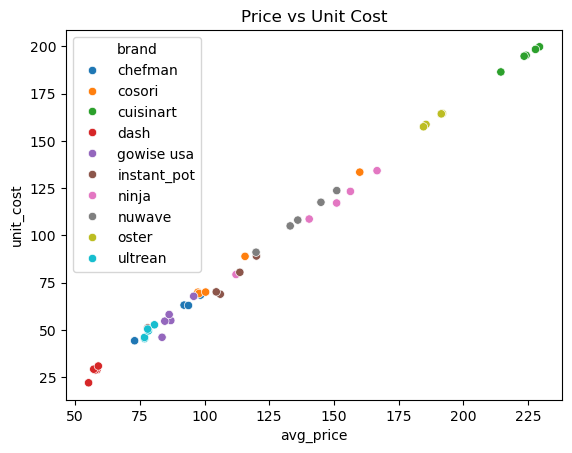

In [233]:
sns.scatterplot(data=df, x='avg_price', y='unit_cost', hue='brand')
plt.title('Price vs Unit Cost')
plt.show()

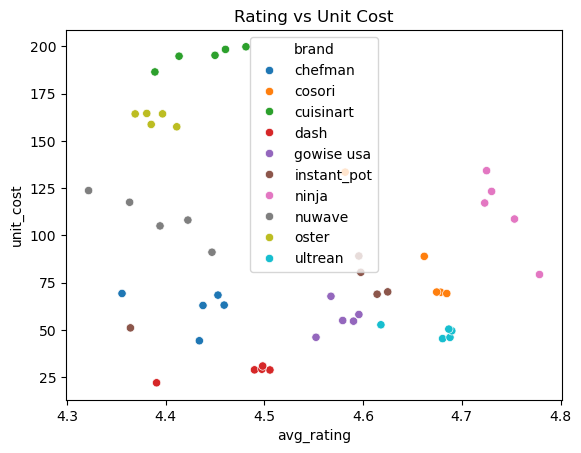

In [234]:
sns.scatterplot(data=df, x='avg_rating', y='unit_cost', hue='brand')
plt.title('Rating vs Unit Cost')
plt.show()

Average Unit Cost vs Average Rating: There's not necessarily a correlation between having a high average unit cost and the average rating. While Cuisinart has a average rating of 4.44 it still had the highest average unit cost of $194.90.

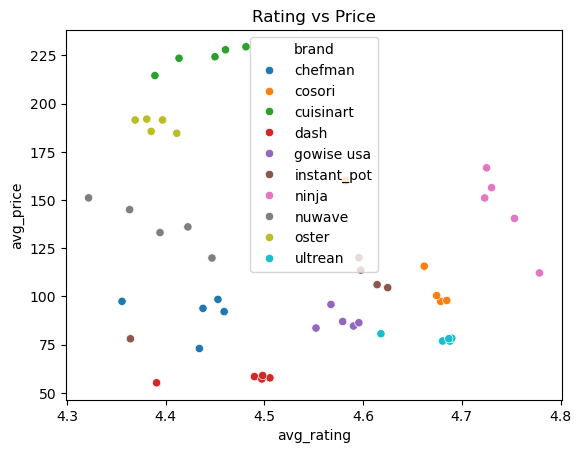

In [235]:
sns.scatterplot(data=df, x='avg_rating', y='avg_price', hue='brand')
plt.title('Rating vs Price')
plt.show()

Expensive Products vs Higher Consumer Satisfaction: There isn't a correlation between expensive products and higher consumer satisfaction. Ninja has the highest average rating, yet Oster and Cuisinart are the two highest in terms of average price.

### Part 4

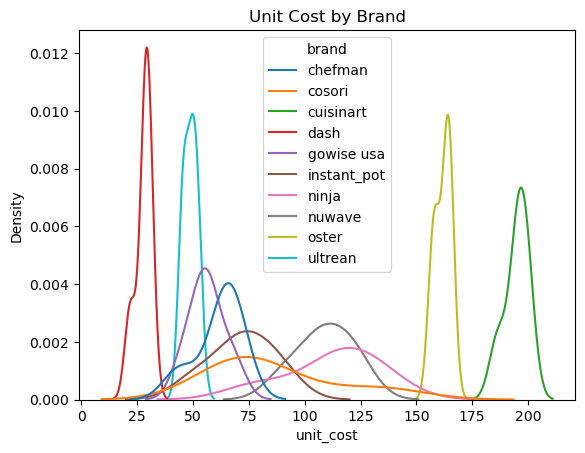

In [236]:
sns.kdeplot(data=df, x='unit_cost', hue='brand')
plt.title('Unit Cost by Brand')
plt.show()

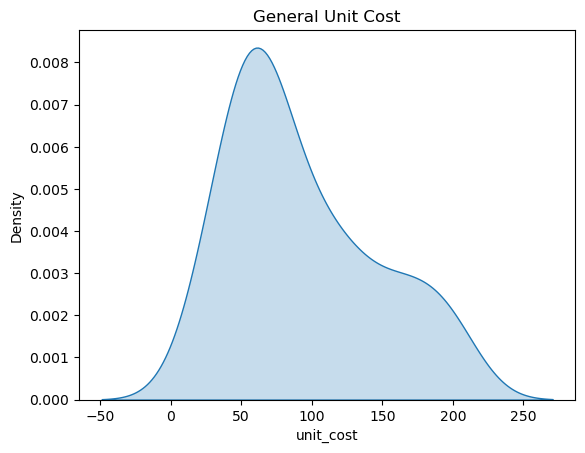

In [237]:
sns.kdeplot(data=df, x='unit_cost', fill=True)
plt.title('General Unit Cost')
plt.show()

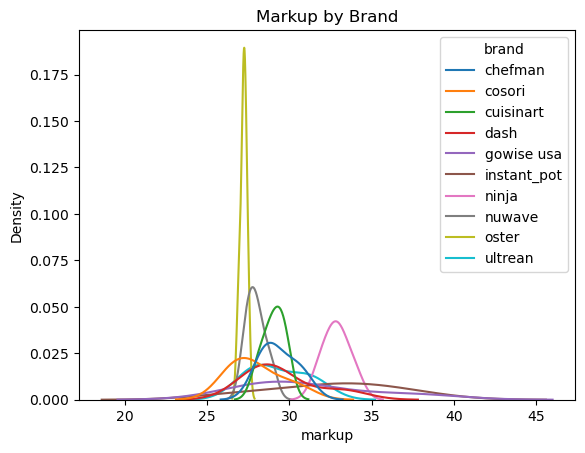

In [238]:
sns.kdeplot(data=df, x='markup', hue='brand')
plt.title('Markup by Brand')
plt.show()

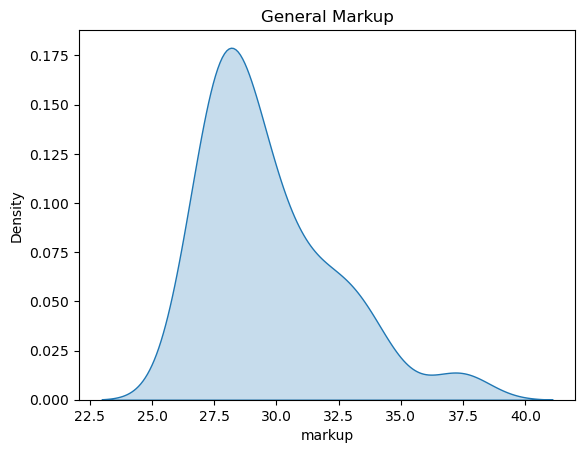

In [239]:
sns.kdeplot(data=df, x='markup', fill=True)
plt.title('General Markup')
plt.show()

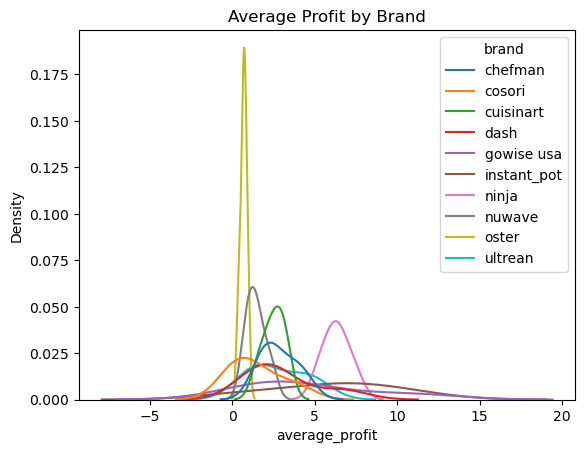

In [240]:
sns.kdeplot(data=df, x='average_profit', hue='brand')
plt.title('Average Profit by Brand')
plt.show()

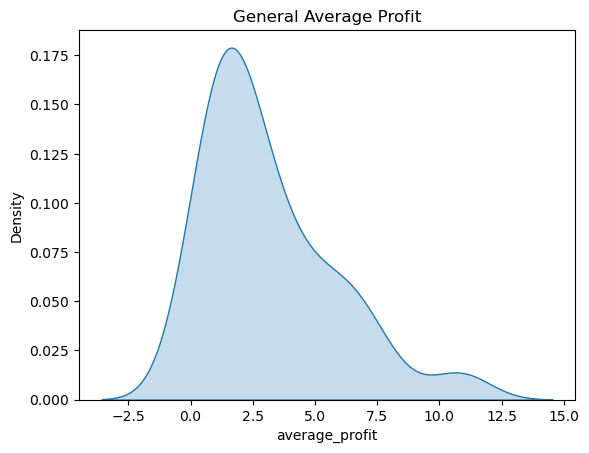

In [241]:
sns.kdeplot(data=df, x='average_profit', fill=True)
plt.title('General Average Profit')
plt.show()

### Part 5

In [242]:
summary_share_weighted = df.groupby('brand')[['average_profit']].mean().sort_values('average_profit', ascending=False)
summary_share_weighted = summary_share_weighted.reset_index()
summary_share_weighted

,brand,average_profit
0,ninja,6.306093
1,instant_pot,6.010256
2,gowise usa,4.605764
3,dash,2.994372
4,chefman,2.820968
5,ultrean,2.780864
6,cuisinart,2.502997
7,cosori,1.436651
8,nuwave,1.422858
9,oster,0.678338


Highest share-weighted average profit: The highest share-weighted average profit is Ninja (6.3), with Instant Pot as second (6.01). This makes sense because they have large market shares. The contrary is true as well, although Cuisinart has highest price and markup, they have a small share, therefore not as much market volume.